<a href="https://colab.research.google.com/github/GomezAleIvan/Coder-Data-III/blob/main/Trabajo_Final_G%C3%B3mez_Alejandro_Data_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
!pip install pandas scikit-learn tensorflow

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

url = "https://raw.githubusercontent.com/GomezAleIvan/Coder-Data-III/refs/heads/main/GYM.csv"
df = pd.read_csv(url)

**EDA**

Filas y Nulos

In [72]:
# Dimensiones
print("Filas:", df.shape[0], "Columnas:", df.shape[1])

# Tipos de datos y valores nulos
print(df.info())
print(df.isnull().sum())

Filas: 80000 Columnas: 5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Gender             80000 non-null  object
 1   Goal               80000 non-null  object
 2   BMI Category       80000 non-null  object
 3   Exercise Schedule  80000 non-null  object
 4   Meal Plan          80000 non-null  object
dtypes: object(5)
memory usage: 3.1+ MB
None
Gender               0
Goal                 0
BMI Category         0
Exercise Schedule    0
Meal Plan            0
dtype: int64


Distribucion de datos

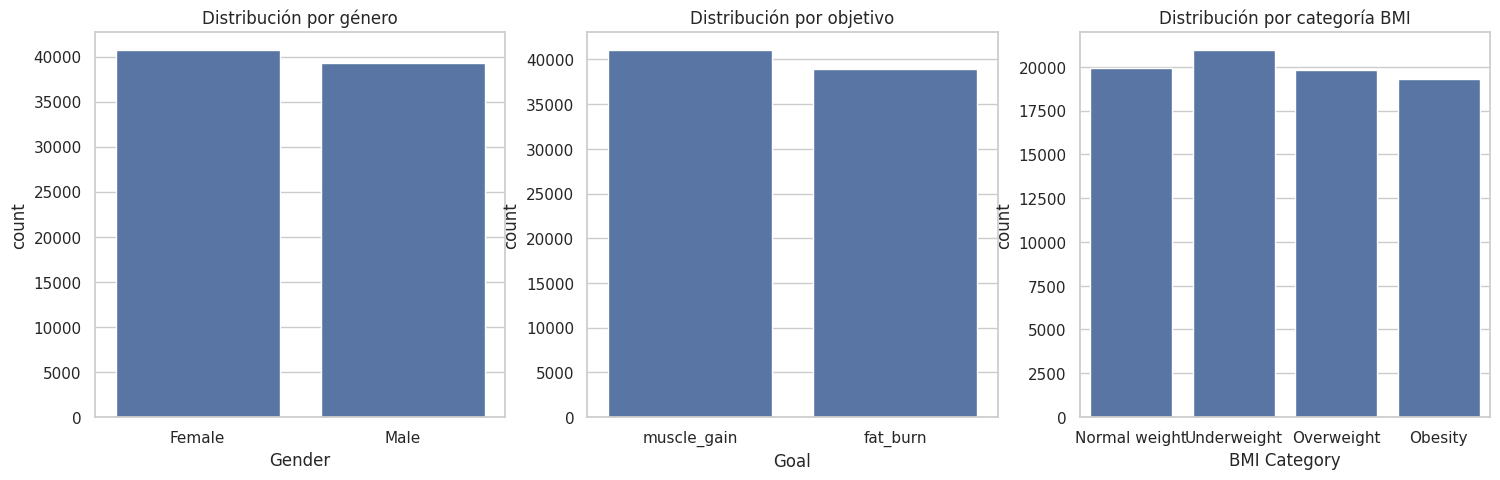

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.countplot(x="Gender", data=df, ax=axes[0])
axes[0].set_title("Distribución por género")

sns.countplot(x="Goal", data=df, ax=axes[1])
axes[1].set_title("Distribución por objetivo")

sns.countplot(x="BMI Category", data=df, ax=axes[2])
axes[2].set_title("Distribución por categoría BMI")

plt.show()

Podemos observar que el dataset esta bastante balanceado

Frecuencias Rutinas y Dietas

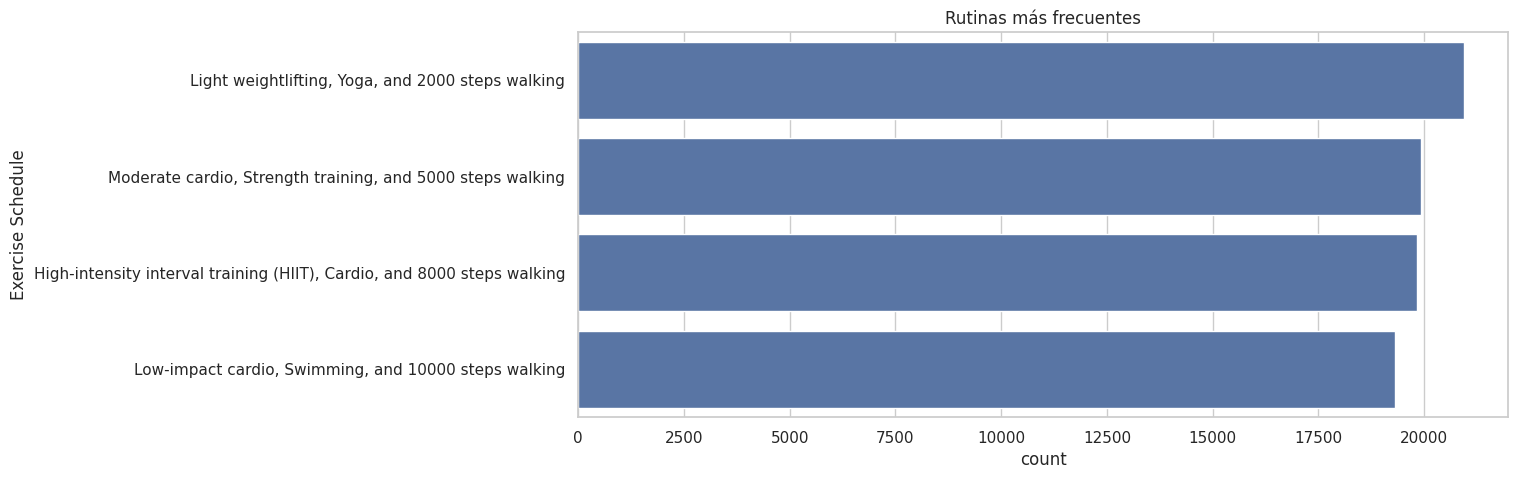

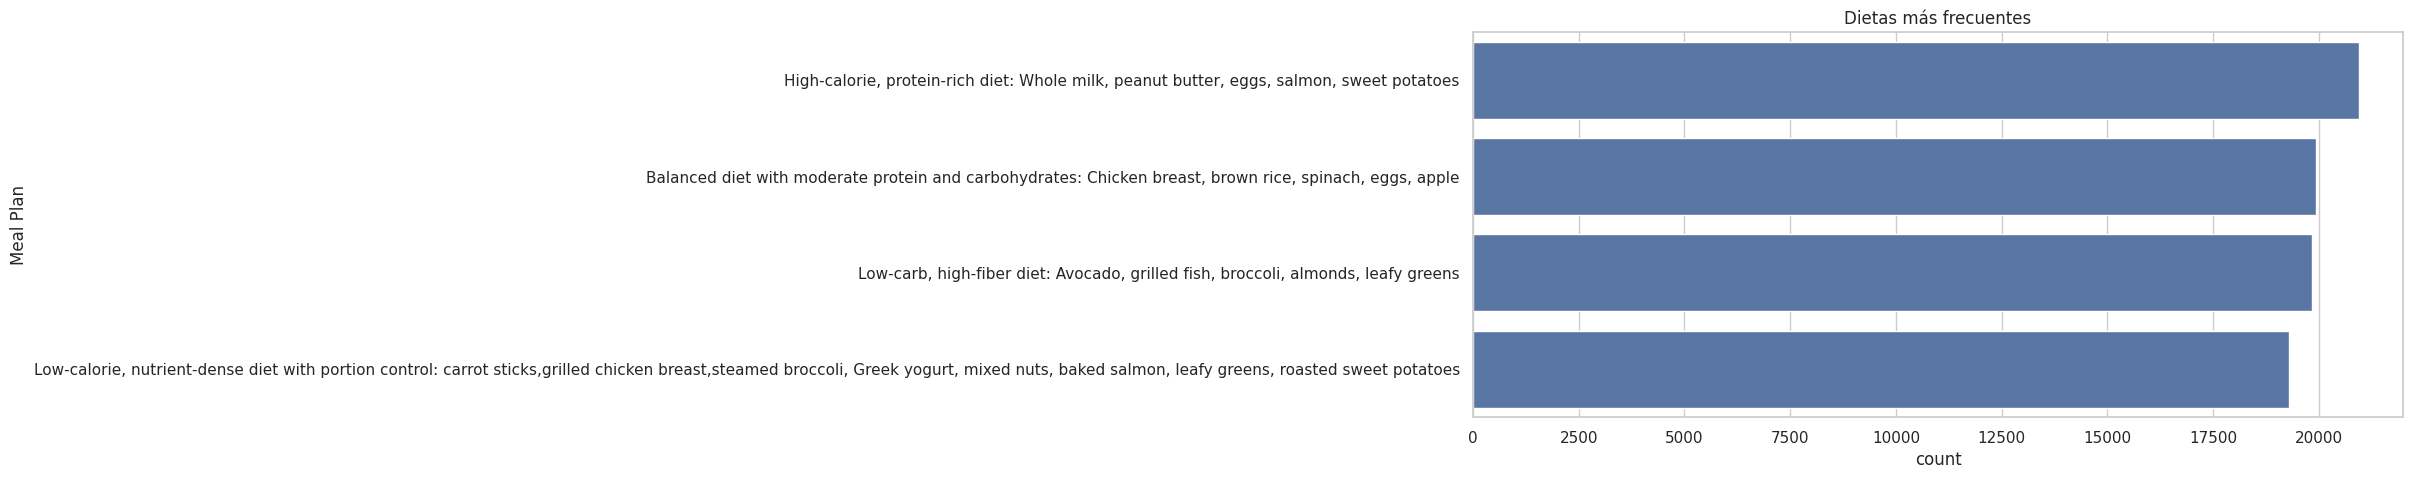

In [74]:
plt.figure(figsize=(12,5))
sns.countplot(y="Exercise Schedule", data=df, order=df["Exercise Schedule"].value_counts().index)
plt.title("Rutinas más frecuentes")
plt.show()

plt.figure(figsize=(12,5))
sns.countplot(y="Meal Plan", data=df, order=df["Meal Plan"].value_counts().index)
plt.title("Dietas más frecuentes")
plt.show()

En cuanto a dietas y rutinas tambien esta balanceado pero empezamos a ver tendencias a dietas altas en calorias y ricas en proteinas mientras que en las rutinas predominan las de baja intensidad

In [75]:
# Etiquetamos Rutina y Dieta
df['label'] = df['Exercise Schedule'].str.strip() + " | " + df['Meal Plan'].str.strip()

Analisis Variables

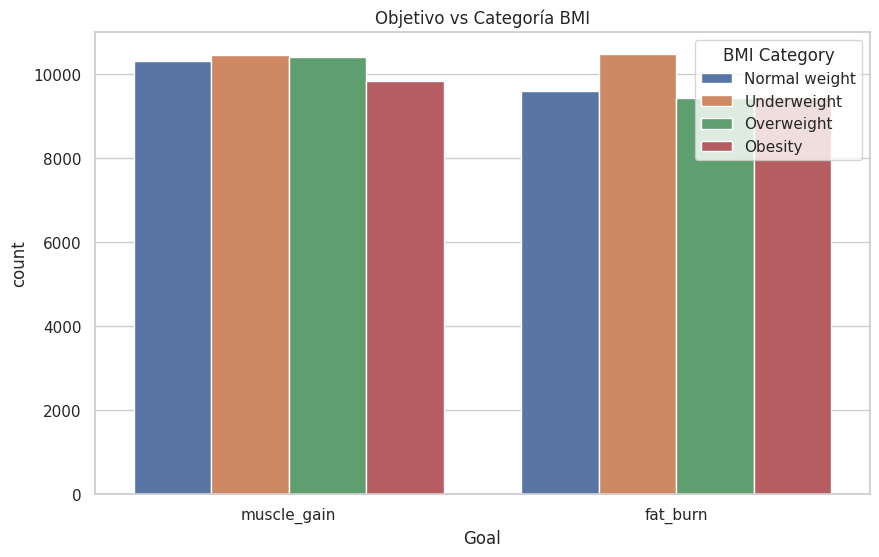

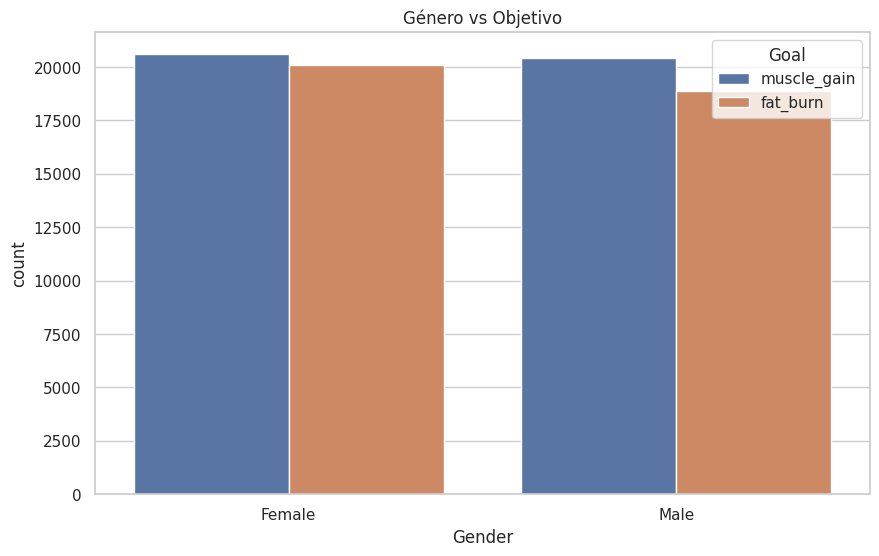

In [76]:
plt.figure(figsize=(10,6))
sns.countplot(x="Goal", hue="BMI Category", data=df)
plt.title("Objetivo vs Categoría BMI")
plt.show()

plt.figure(figsize=(10,6))
sns.countplot(x="Gender", hue="Goal", data=df)
plt.title("Género vs Objetivo")
plt.show()

Vemos que el objetivo mas comun es la ganancia muscular sin importar el genero. Es curioso en el caso de la gente delgada (underweight) tiene como objetivo quemar grasa.

In [82]:
from sklearn.preprocessing import LabelEncoder

# Salidas: rutina y dieta
y_routine = df['RoutineCategory']
y_diet = df['DietCategory']

# Codificar etiquetas
routine_encoder = LabelEncoder()
diet_encoder = LabelEncoder()

y_routine_train_idx = routine_encoder.fit_transform(y_routine_train)
y_routine_test_idx = routine_encoder.transform(y_routine_test)

y_diet_train_idx = diet_encoder.fit_transform(y_diet_train)
y_diet_test_idx = diet_encoder.transform(y_diet_test)

# Definir número de clases
num_routines = len(routine_encoder.classes_)
num_diets = len(diet_encoder.classes_)

KeyError: 'RoutineCategory'

Modelo 1

In [84]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_simple_model(input_dim, num_classes,
                       hidden_units=[64,32],
                       dropout_rate=0.2,
                       learning_rate=0.001):
    inputs = layers.Input(shape=(input_dim,))
    x = inputs
    for units in hidden_units:
        x = layers.Dense(units, activation='relu')(x)
        x = layers.Dropout(dropout_rate)(x)

    output = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [87]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y_train_idx = encoder.fit_transform(y_train)
y_test_idx = encoder.transform(y_test)
num_classes = len(encoder.classes_)

Entrenamiento Modelo 1

In [88]:
model = build_simple_model(X_train_vec.shape[1], num_classes,
                           hidden_units=[128,64], dropout_rate=0.3)
history = model.fit(X_train_vec, y_train_idx,
                    validation_data=(X_test_vec, y_test_idx),
                    epochs=20, batch_size=16, verbose=1)

Epoch 1/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9941 - loss: 0.0215 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 1.0000 - loss: 4.1978e-06 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 1.0000 - loss: 2.9112e-07 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 1.0000 - loss: 4.6660e-08 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 1.0000 - loss: 7.1351e-09 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 1.0000 - loss: 1.9367e-09 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 1.0000 - loss: 3.4321e-09 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/20
4000/4000 ━━━━━━━━━━

Evaluacion Modelo 1

Accuracy en test: 1.000
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
Accuracy de validación por época (Modelo 1): [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Accuracy de validación final (Modelo 1): 1.0


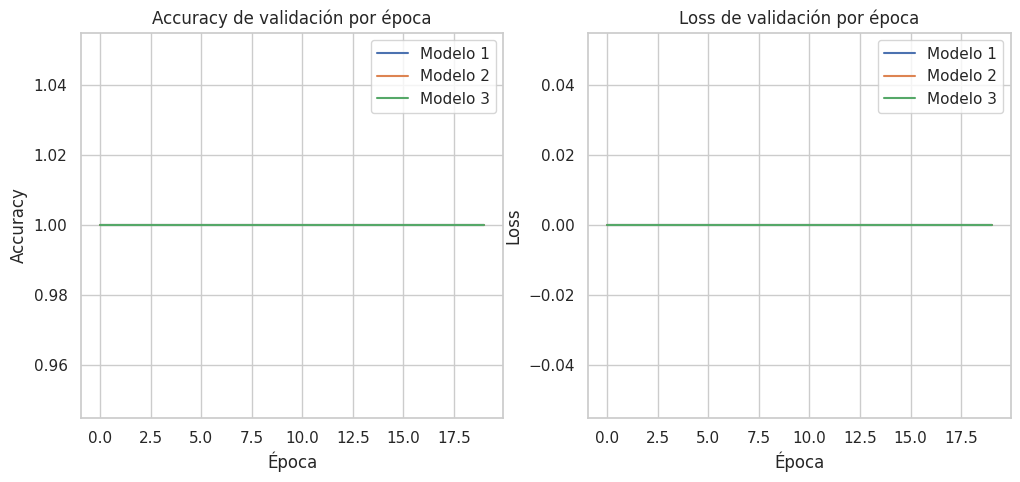

In [104]:
test_loss, test_acc = model.evaluate(X_test_vec, y_test_idx, verbose=0)
print(f"Accuracy en test: {test_acc:.3f}")
print(history.history.keys())

val_acc_model = history.history['val_accuracy']
print("Accuracy de validación por época (Modelo 1):", val_acc_model)

print("Accuracy de validación final (Modelo 1):", val_acc_model[-1])
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['val_accuracy'], label='Modelo 1')
plt.plot(history2.history['val_accuracy'], label='Modelo 2')
plt.plot(history3.history['val_accuracy'], label='Modelo 3')
plt.title('Accuracy de validación por época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['val_loss'], label='Modelo 1')
plt.plot(history2.history['val_loss'], label='Modelo 2')
plt.plot(history3.history['val_loss'], label='Modelo 3')
plt.title('Loss de validación por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.show()

Caso Nuevo Modelo 1

In [91]:
sample_input = pd.DataFrame([{
    'Gender': 'Male',
    'Goal': 'fat_burn',
    'BMI Category': 'Overweight',
    'text': ''
}])

sample_vec = preprocess.transform(sample_input)

pred_probs = model.predict(sample_vec)
pred_idx = pred_probs.argmax(axis=1)[0]

print("Predicción:", encoder.classes_[pred_idx])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
Predicción: High-intensity interval training (HIIT), Cardio, and 8000 steps walking | Low-carb, high-fiber diet: Avocado, grilled fish, broccoli, almonds, leafy greens


Modelo 2 con mas neuronas y mas regularización

Epoch 1/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9913 - loss: 0.0288 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 1.0000 - loss: 5.5043e-06 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 1.0000 - loss: 2.8382e-06 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 1.0000 - loss: 6.9747e-08 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 1.0000 - loss: 9.0548e-09 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 1.0000 - loss: 2.8579e-09 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 1.0000 - loss: 8.5779e-09 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/20
4000/4000 ━━━━━━━━━━

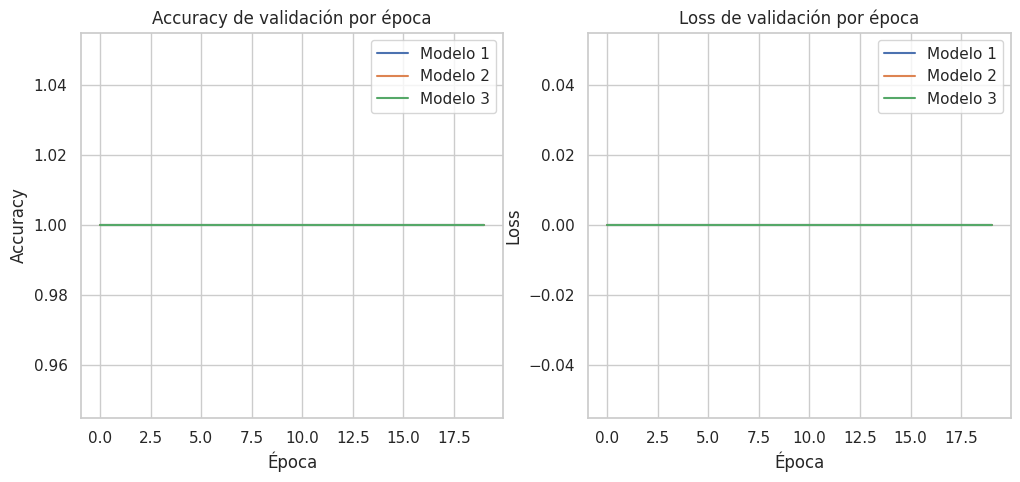

In [103]:
def build_model2(input_dim, num_classes,
                 hidden_units=[128,64],
                 dropout_rate=0.3,
                 learning_rate=0.001):
    inputs = layers.Input(shape=(input_dim,))
    x = inputs
    for units in hidden_units:
        x = layers.Dense(units, activation='relu')(x)
        x = layers.Dropout(dropout_rate)(x)

    output = layers.Dense(num_classes, activation='softmax')(x)

    model2 = models.Model(inputs=inputs, outputs=output)
    model2.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model2

model2 = build_model2(
    input_dim=X_train_vec.shape[1],
    num_classes=num_classes,
    hidden_units=[128,64],
    dropout_rate=0.3,
    learning_rate=0.001
)

history2 = model2.fit(
    X_train_vec, y_train_idx,
    validation_data=(X_test_vec, y_test_idx),
    epochs=20,
    batch_size=16,
    verbose=1
)

results2 = model2.evaluate(X_test_vec, y_test_idx, verbose=0)
print(f"Accuracy Modelo 2: {results2[1]:.3f}")
print(history2.history.keys())

val_acc_model2 = history2.history['val_accuracy']
print("Accuracy de validación por época (Modelo 2):", val_acc_model2)

print("Accuracy de validación final (Modelo 2):", val_acc_model2[-1])
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['val_accuracy'], label='Modelo 1')
plt.plot(history2.history['val_accuracy'], label='Modelo 2')
plt.plot(history3.history['val_accuracy'], label='Modelo 3')
plt.title('Accuracy de validación por época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['val_loss'], label='Modelo 1')
plt.plot(history2.history['val_loss'], label='Modelo 2')
plt.plot(history3.history['val_loss'], label='Modelo 3')
plt.title('Loss de validación por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.show()

Ejemplo Modelo 2

In [97]:
sample_input2 = pd.DataFrame([{
    'Gender': 'Female',
    'Goal': 'fat_burn',
    'BMI Category': 'Normal',
    'text': ''
}])

sample_vec2 = preprocess.transform(sample_input2)

pred_probs2 = model2.predict(sample_vec2)
pred_idx2 = pred_probs2.argmax(axis=1)[0]

print("Predicción Modelo 2:", encoder.classes_[pred_idx2])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predicción Modelo 2: High-intensity interval training (HIIT), Cardio, and 8000 steps walking | Low-carb, high-fiber diet: Avocado, grilled fish, broccoli, almonds, leafy greens


Modelo 3 aumentamos mas capas y regularazión nuevamente

In [98]:
def build_model3(input_dim, num_classes,
                 hidden_units=[256,128,64],
                 dropout_rate=0.4,
                 learning_rate=0.0005):
    inputs = layers.Input(shape=(input_dim,))
    x = inputs
    for units in hidden_units:
        x = layers.Dense(units, activation='relu')(x)
        x = layers.Dropout(dropout_rate)(x)

    output = layers.Dense(num_classes, activation='softmax')(x)

    model3 = models.Model(inputs=inputs, outputs=output)
    model3.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model3

model3 = build_model3(
    input_dim=X_train_vec.shape[1],
    num_classes=num_classes,
    hidden_units=[256,128,64],
    dropout_rate=0.4,
    learning_rate=0.0005
)

history3 = model3.fit(
    X_train_vec, y_train_idx,
    validation_data=(X_test_vec, y_test_idx),
    epochs=20,
    batch_size=16,
    verbose=1
)

results3 = model3.evaluate(X_test_vec, y_test_idx, verbose=0)
print(f"Accuracy Modelo 2: {results2[1]:.3f}")
print(history2.history.keys())

val_acc_model3 = history3.history['val_accuracy']
print("Accuracy de validación por época (Modelo 3):", val_acc_model3)

print("Accuracy de validación final (Modelo 3):", val_acc_model3[-1])
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['val_accuracy'], label='Modelo 1')
plt.plot(history2.history['val_accuracy'], label='Modelo 2')
plt.plot(history3.history['val_accuracy'], label='Modelo 3')
plt.title('Accuracy de validación por época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['val_loss'], label='Modelo 1')
plt.plot(history2.history['val_loss'], label='Modelo 2')
plt.plot(history3.history['val_loss'], label='Modelo 3')
plt.title('Loss de validación por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.show()

Epoch 1/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.9846 - loss: 0.0511 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 1.0000 - loss: 1.8443e-05 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 1.0000 - loss: 1.9798e-05 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 1.0000 - loss: 1.7686e-05 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 1.0000 - loss: 8.1884e-07 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 1.0000 - loss: 1.0802e-07 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 1.0000 - loss: 1.0698e-05 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/20
4000/4000 ━━━━━━━━━━

Ejemplo Modelo 3

In [99]:
sample_input3 = pd.DataFrame([{
    'Gender': 'Male',
    'Goal': 'muscle_gain',
    'BMI Category': 'Obesity',
    'text': ''
}])

sample_vec3 = preprocess.transform(sample_input3)

pred_probs3 = model3.predict(sample_vec3)
pred_idx3 = pred_probs3.argmax(axis=1)[0]

print("Predicción Modelo 3:", encoder.classes_[pred_idx3])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Predicción Modelo 3: Light weightlifting, Yoga, and 2000 steps walking | High-calorie, protein-rich diet: Whole milk, peanut butter, eggs, salmon, sweet potatoes
